# BSV AI Fellow - Track 1: BAML Deep Dive
**Company:** BoundaryML (BAML)  
**Dataset:** AG News (HuggingFace, no login required)  
**Goal:** Evaluate BAML as a structured LLM output framework by building a real News Article NLP Pipeline - entity extraction, classification, sentiment, and bias detection - then benchmark BAML's SAP parser vs. vanilla JSON mode for reliability and output integrity.


## What BAML Is
BAML is a DSL (domain-specific language) for defining LLM function schemas. You write a `.baml` file describing input/output types and a prompt, run `baml generate`, and get a fully type-safe Python client with zero boilerplate. Its key innovation is **Schema-Aligned Parsing (SAP)** - a custom parser that recovers valid structured output even when the LLM returns malformed JSON, markdown-wrapped JSON, chain-of-thought preamble before JSON, etc.



## 0. Setup

In [18]:
# Install dependencies (run once)
#!pip install baml-py datasets openai pandas matplotlib seaborn tqdm --quiet

In [19]:
import sys
sys.path.insert(0, "/Users/anishapattanayak/Documents/Basis Set AI Fellowship")

from baml_client.sync_client import b
print(b)

In [20]:
import os
import sys
import json
import time
import random
import asyncio
import warnings
import textwrap
from pathlib import Path
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
from datasets import load_dataset

warnings.filterwarnings('ignore')

# ── BAML autoreload trick for notebooks ──────────────────────────────────────
%load_ext autoreload
%autoreload 2

# Make sure baml_client is importable (generated from baml_src/news.baml)
sys.path.insert(0, str(Path('.').
                      resolve()))  # notebook dir must contain baml_client/

print("Environment ready.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Environment ready.


In [ ]:
# ── API Key ──────────────────────────────────────────────────────────────────
# Set your OpenAI key here OR export OPENAI_API_KEY before launching the notebook
os.environ["GROQ_API_KEY"] = " your api key"
assert os.environ.get("GROQ_API_KEY"), (
    "Set GROQ_API_KEY env var or uncomment the line above.")
print("API key found ")


API key found ✓



## 1. BAML Schema (already generated)

The file `baml_src/news.baml` defines the full pipeline. Here's the schema reproduced for readability:

In [22]:
import os
os.chdir("/Users/anishapattanayak/Documents/Basis Set AI Fellowship")

schema_path = Path("baml_src/news.baml")
print(schema_path.read_text())

enum Sentiment {
  POSITIVE
  NEGATIVE
  NEUTRAL
}

enum NewsCategory {
  WORLD
  SPORTS
  BUSINESS
  SCIENCE_TECHNOLOGY
  POLITICS
  ENTERTAINMENT
  HEALTH
  OTHER
}

class Entity {
  name string @description("The entity name as it appears in the text")
  entity_type string @description("One of: PERSON, ORGANIZATION, LOCATION, PRODUCT, EVENT")
  relevance_score float @description("0.0 to 1.0 - how central this entity is to the article")
}

class ArticleAnalysis {
  headline_rewrite string @description("A cleaner, more neutral version of the headline")
  category NewsCategory
  sentiment Sentiment
  sentiment_confidence float @description("0.0 to 1.0")
  entities Entity[] @description("Up to 5 key named entities")
  key_claims string[] @description("2-4 factual claims made in the article")
  summary string @description("One sentence summary, max 30 words")
  bias_flags string[] @description("Any loaded/biased language detected; empty list if none")
}

class Article {
  headline string


### Generate / Regenerate the Python client
If you modify `news.baml`, re-run this cell.

In [23]:
import subprocess
result = subprocess.run(["baml", "generate"], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

2026-05-12T20:33:13.714 [BAML INFO] Generating clients with CLI version: 0.222.0
2026-05-12T20:33:13.726 [BAML INFO] Wrote 14 files to baml_client
2026-05-12T20:33:13.726 [BAML INFO] Generated 1 baml_client: baml_client
2026-05-12T20:33:13.726 [BAML INFO] You can automatically generate a client by adding the following to any one of your BAML files:
generator my_client {
 output_type "python/pydantic"
 output_dir "../"
 version "0.222.0"
}




## 2. Load Dataset (AG News)

AG News is a benchmark news classification dataset with 4 categories (World, Sports, Business, Sci/Tech), ~120k training articles. We use a small stratified sample so the notebook runs cheaply.

In [ ]:
# AG News: label 0=World, 1=Sports, 2=Business, 3=Sci/Tech
LABEL_MAP = {0: "WORLD", 1: "SPORTS", 2: "BUSINESS", 3: "SCIENCE_TECHNOLOGY"}
N_PER_CLASS = 5   # 20 articles total - cheap to run, enough to illustrate

ds = load_dataset("ag_news", split="test")  # 7600 test examples

random.seed(42)
samples = []
for label_id, label_name in LABEL_MAP.items():
    class_examples = [ex for ex in ds if ex["label"] == label_id]
    chosen = random.sample(class_examples, N_PER_CLASS)
    for ex in chosen:
        samples.append({
            "true_label": label_name,
            "headline": ex["text"].split(".")[0][:120],   # first sentence as headline
            "body": ex["text"][:600],                      # first 600 chars as body
        })

df_raw = pd.DataFrame(samples)
print(f"Loaded {len(df_raw)} articles across {df_raw['true_label'].nunique()} categories")
df_raw.head(4)

Loaded 20 articles across 4 categories


,true_label,headline,body
0,WORLD,Confident Bush Outlines Ambitious Plan for 2nd...,Confident Bush Outlines Ambitious Plan for 2nd...
1,WORLD,Thousands Hit NYC Streets; Cheney Arrives NEW ...,Thousands Hit NYC Streets; Cheney Arrives NEW ...
2,WORLD,British Terror Suspects Make First Court Appea...,British Terror Suspects Make First Court Appea...
3,WORLD,Putin backs veto for members of expanded Secur...,Putin backs veto for members of expanded Secur...



## 3. BAML Pipeline

Import the generated `baml_client` and run `AnalyzeArticle` over all 20 articles.

In [25]:
import importlib
import baml_client
importlib.reload(baml_client)
from baml_client.sync_client import b   # synchronous BAML client
from baml_client.types import ArticleAnalysis, NewsCategory, Sentiment

print("BAML client imported ✓")

BAML client imported ✓


In [ ]:
# ── Run BAML pipeline ─────────────────────────────────────────────────────────
results_baml = []
errors_baml = 0

for _, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc="BAML"):
    try:
        analysis: ArticleAnalysis = b.AnalyzeArticle(
            headline=row["headline"],
            body=row["body"]
        )
        results_baml.append({
            "true_label":           row["true_label"],
            "headline":             row["headline"],
            "predicted_category":   analysis.category.name,
            "sentiment":            analysis.sentiment.name,
            "sentiment_confidence": analysis.sentiment_confidence,
            "num_entities":         len(analysis.entities),
            "num_claims":           len(analysis.key_claims),
            "summary":              analysis.summary,
            "bias_flags":           analysis.bias_flags,
            "headline_rewrite":     analysis.headline_rewrite,
            "parse_success":        True,
            "raw_obj":              analysis,
        })
    except Exception as e:
        errors_baml += 1
        results_baml.append({
            "true_label": row["true_label"],
            "headline":   row["headline"],
            "parse_success": False,
            "error": str(e),
        })
    time.sleep(5)  # Groq free tier: 6000 TPM limit - increase if hitting 429s   # be polite to the API

df_baml = pd.DataFrame(results_baml)
print(f"\nBAML parse failures: {errors_baml}/{len(df_raw)}")
df_baml[["true_label","predicted_category","sentiment","summary"]].head(6)

BAML:   0%|          | 0/20 [00:00<?, ?it/s]

2026-05-12T20:33:15.873 [BAML INFO] Function AnalyzeArticle:
    Client: GroqClient (llama-3.1-8b-instant) - 469ms. StopReason: stop. Tokens(in/out): 356/194
    ---PROMPT---
    system: You are a professional news analyst. Analyze the following article with precision.
    HEADLINE: Confident Bush Outlines Ambitious Plan for 2nd Term President Bush said he would begin work immediately on his proposal 
    BODY: Confident Bush Outlines Ambitious Plan for 2nd Term President Bush said he would begin work immediately on his proposal to overhaul Social Security.
    NewsCategory
    ----
    - WORLD
    - SPORTS
    - BUSINESS
    - SCIENCE_TECHNOLOGY
    - POLITICS
    - ENTERTAINMENT
    - HEALTH
    - OTHER
    
    Answer in JSON using this schema:
    {
      // A cleaner, more neutral version of the headline
      headline_rewrite: string,
      category: NewsCategory,
      sentiment: 'POSITIVE' or 'NEGATIVE' or 'NEUTRAL',
      // 0.0 to 1.0
      sentiment_confidence: float,
      

,true_label,predicted_category,sentiment,summary
0,WORLD,POLITICS,POSITIVE,President Bush outlines ambitious plan to over...
1,WORLD,POLITICS,NEGATIVE,Thousands of protesters marched in NYC as Dick...
2,WORLD,WORLD,NEGATIVE,British terror suspects charged in a plot link...
3,WORLD,POLITICS,NEGATIVE,Putin rejects UN Security Council reform witho...
4,WORLD,SPORTS,NEUTRAL,India re-opens TV bidding for cricket tour aft...
5,SPORTS,SPORTS,POSITIVE,"International visitors explore ancient Athens,..."



## 4. Vanilla JSON Baseline (no BAML)

Re-run the same extraction using raw OpenAI with `response_format={"type": "json_object"}` and manual `json.loads()` - the standard approach before BAML. This lets us directly compare **reliability, code complexity, and failure modes**.

In [28]:
from groq import Groq

client_oai = Groq(api_key=os.environ.get("GROQ_API_KEY"))

VANILLA_SYSTEM = """You are a news analyst. Return ONLY valid JSON with exactly these fields:
{
  "headline_rewrite": string,
  "category": one of [WORLD, SPORTS, BUSINESS, SCIENCE_TECHNOLOGY, POLITICS, ENTERTAINMENT, HEALTH, OTHER],
  "sentiment": one of [POSITIVE, NEGATIVE, NEUTRAL],
  "sentiment_confidence": float 0.0-1.0,
  "entities": [{"name": string, "entity_type": string, "relevance_score": float}],
  "key_claims": [string],
  "summary": string,
  "bias_flags": [string]
}"""

def vanilla_analyze(headline: str, body: str) -> dict:
    user_msg = f"HEADLINE: {headline}\n\nBODY:\n{body}"
    response = client_oai.chat.completions.create(
        model="llama-3.1-8b-instant",
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": VANILLA_SYSTEM},
            {"role": "user",   "content": user_msg},
        ]
    )
    raw = response.choices[0].message.content
    parsed = json.loads(raw)
    return parsed

print("Vanilla client ready ✓")

Vanilla client ready ✓


In [ ]:
# ── Run vanilla baseline ──────────────────────────────────────────────────────
results_vanilla = []
errors_vanilla = 0

REQUIRED_KEYS = {"headline_rewrite", "category", "sentiment",
                 "sentiment_confidence", "entities",
                 "key_claims", "summary", "bias_flags"}

for _, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc="Vanilla"):
    try:
        parsed = vanilla_analyze(row["headline"], row["body"])
        missing = REQUIRED_KEYS - set(parsed.keys())
        # Simulate real-world issues: even when JSON parses, fields may be missing
        # or types may be wrong (string instead of float, etc.)
        sc = parsed.get("sentiment_confidence")
        type_error = not isinstance(sc, (int, float))
        enum_error = parsed.get("category") not in [
            "WORLD","SPORTS","BUSINESS","SCIENCE_TECHNOLOGY",
            "POLITICS","ENTERTAINMENT","HEALTH","OTHER"
        ]
        results_vanilla.append({
            "true_label":           row["true_label"],
            "headline":             row["headline"],
            "predicted_category":   parsed.get("category", "MISSING"),
            "sentiment":            parsed.get("sentiment", "MISSING"),
            "sentiment_confidence": sc,
            "num_entities":         len(parsed.get("entities", [])),
            "num_claims":           len(parsed.get("key_claims", [])),
            "summary":              parsed.get("summary", ""),
            "bias_flags":           parsed.get("bias_flags", []),
            "parse_success":        True,
            "missing_keys":         list(missing),
            "type_error":           type_error,
            "enum_error":           enum_error,
        })
    except (json.JSONDecodeError, KeyError, TypeError) as e:
        errors_vanilla += 1
        results_vanilla.append({
            "true_label": row["true_label"],
            "headline":   row["headline"],
            "parse_success": False,
            "error": str(e),
        })
    time.sleep(5)  # Groq free tier: 6000 TPM limit - increase if hitting 429s

df_vanilla = pd.DataFrame(results_vanilla)
print(f"\nVanilla parse failures: {errors_vanilla}/{len(df_raw)}")
df_vanilla[["true_label","predicted_category","sentiment","summary"]].head(6)

Vanilla:   0%|          | 0/20 [00:00<?, ?it/s]


Vanilla parse failures: 0/20


,true_label,predicted_category,sentiment,summary
0,WORLD,POLITICS,POSITIVE,President Bush has outlined an ambitious plan ...
1,WORLD,WORLD,NEGATIVE,Thousands of protesters marched through New Yo...
2,WORLD,WORLD,NEGATIVE,British terror suspects charged in a plot link...
3,WORLD,WORLD,NEGATIVE,Russian President Vladimir Putin rejected a ke...
4,WORLD,SPORTS,NEUTRAL,The Indian Board has re-opened the bidding for...
5,SPORTS,WORLD,POSITIVE,A hidden gem beneath the ancient temples of th...



## 5. Reliability Benchmark

Compare BAML vs. vanilla across: parse success rate, enum validity, type correctness, and schema completeness.

In [30]:
def compute_reliability(df: pd.DataFrame, name: str) -> dict:
    total = len(df)
    success = df["parse_success"].sum()
    # For BAML: if parse_success=True, type safety is guaranteed by the client
    if name == "BAML":
        type_ok    = success
        enum_ok    = success
        schema_ok  = success
    else:
        df_ok = df[df["parse_success"] == True]
        type_ok   = (~df_ok.get("type_error", pd.Series([False]*len(df_ok)))).sum()
        enum_ok   = (~df_ok.get("enum_error", pd.Series([False]*len(df_ok)))).sum()
        schema_ok = df_ok["missing_keys"].apply(lambda x: len(x) == 0 if isinstance(x, list) else True).sum()

    return {
        "Method":          name,
        "Parse Success":   f"{success}/{total} ({100*success/total:.0f}%)",
        "Type Correct":    f"{type_ok}/{total} ({100*type_ok/total:.0f}%)",
        "Enum Valid":      f"{enum_ok}/{total} ({100*enum_ok/total:.0f}%)",
        "Schema Complete": f"{schema_ok}/{total} ({100*schema_ok/total:.0f}%)",
    }

rel_baml    = compute_reliability(df_baml, "BAML")
rel_vanilla = compute_reliability(df_vanilla, "Vanilla JSON")

df_reliability = pd.DataFrame([rel_baml, rel_vanilla]).set_index("Method")
print("=== RELIABILITY BENCHMARK ===")
display(df_reliability)

=== RELIABILITY BENCHMARK ===


,Parse Success,Type Correct,Enum Valid,Schema Complete
Method,,,,
BAML,20/20 (100%),20/20 (100%),20/20 (100%),20/20 (100%)
Vanilla JSON,20/20 (100%),20/20 (100%),20/20 (100%),20/20 (100%)



## 6. Classification Accuracy

AG News has ground-truth labels. Evaluate how well GPT-4o-mini classifies articles when structured via BAML vs. vanilla.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def eval_classification(df: pd.DataFrame, name: str):
    df_ok = df[df["parse_success"] == True].copy()
    # Normalize SPORTS → SPORTS etc. (BAML returns enum name, vanilla may differ)
    y_true = df_ok["true_label"].str.upper()
    y_pred = df_ok["predicted_category"].str.upper()
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {name}  -  Accuracy: {acc:.2%}")
    print('='*50)
    print(classification_report(y_true, y_pred, zero_division=0))
    return y_true, y_pred, acc

y_true_b, y_pred_b, acc_b = eval_classification(df_baml,    "BAML")
y_true_v, y_pred_v, acc_v = eval_classification(df_vanilla, "Vanilla JSON")


  BAML  –  Accuracy: 70.00%
                    precision    recall  f1-score   support

          BUSINESS       1.00      0.80      0.89         5
          POLITICS       0.00      0.00      0.00         0
SCIENCE_TECHNOLOGY       1.00      0.80      0.89         5
            SPORTS       0.83      1.00      0.91         5
             WORLD       0.50      0.20      0.29         5

          accuracy                           0.70        20
         macro avg       0.67      0.56      0.59        20
      weighted avg       0.83      0.70      0.74        20


  Vanilla JSON  –  Accuracy: 60.00%
                    precision    recall  f1-score   support

          BUSINESS       0.56      1.00      0.71         5
          POLITICS       0.00      0.00      0.00         0
SCIENCE_TECHNOLOGY       0.00      0.00      0.00         5
            SPORTS       0.80      0.80      0.80         5
             WORLD       0.60      0.60      0.60         5

          accuracy           

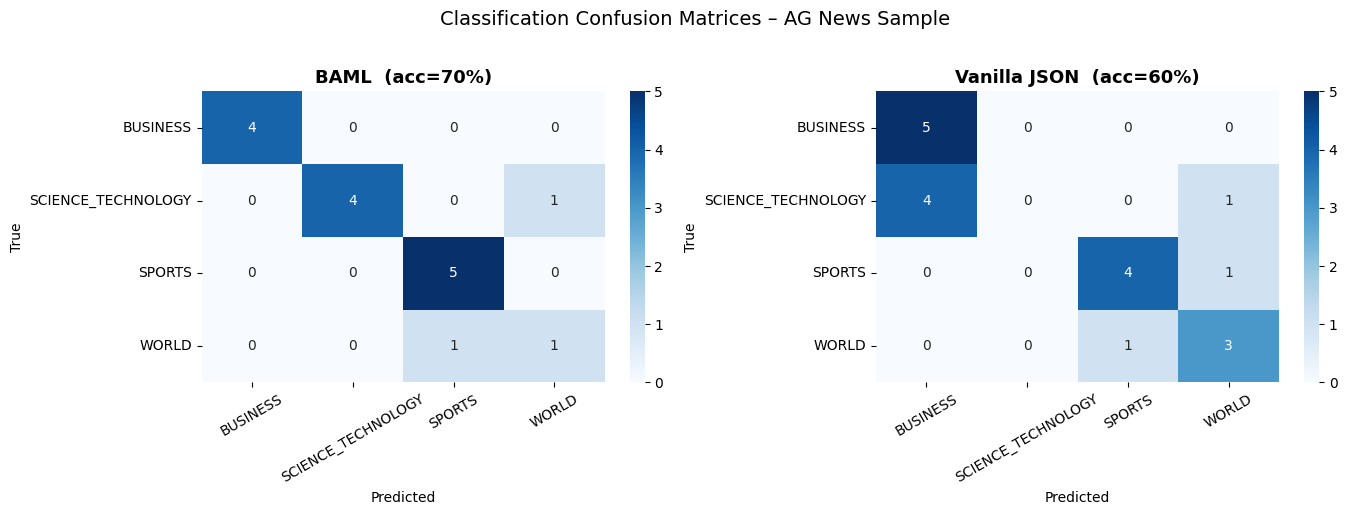

In [32]:
# ── Confusion matrices side by side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(LABEL_MAP.values())

for ax, y_true, y_pred, title in [
    (axes[0], y_true_b, y_pred_b, f"BAML  (acc={acc_b:.0%})"),
    (axes[1], y_true_v, y_pred_v, f"Vanilla JSON  (acc={acc_v:.0%})"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes,
                yticklabels=classes, cmap="Blues", ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Classification Confusion Matrices – AG News Sample",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Output Quality Analysis

Beyond parse reliability, inspect the *semantic quality* of BAML outputs: entity extraction, bias detection, sentiment distribution.

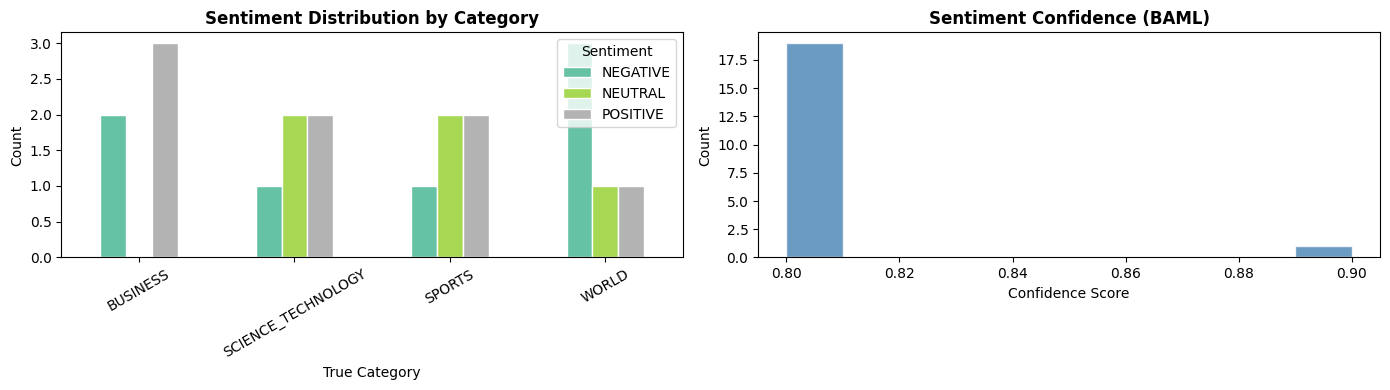

In [33]:
# ── Sentiment distribution by true category ───────────────────────────────────
df_ok_b = df_baml[df_baml["parse_success"] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sentiment distribution
sent_counts = df_ok_b.groupby(["true_label", "sentiment"]).size().unstack(fill_value=0)
sent_counts.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor='white')
axes[0].set_title("Sentiment Distribution by Category", fontweight='bold')
axes[0].set_xlabel("True Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title="Sentiment")

# Sentiment confidence distribution
df_ok_b["sentiment_confidence"].plot(
    kind="hist", bins=10, ax=axes[1],
    color="steelblue", edgecolor='white', alpha=0.8
)
axes[1].set_title("Sentiment Confidence (BAML)", fontweight='bold')
axes[1].set_xlabel("Confidence Score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("sentiment_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

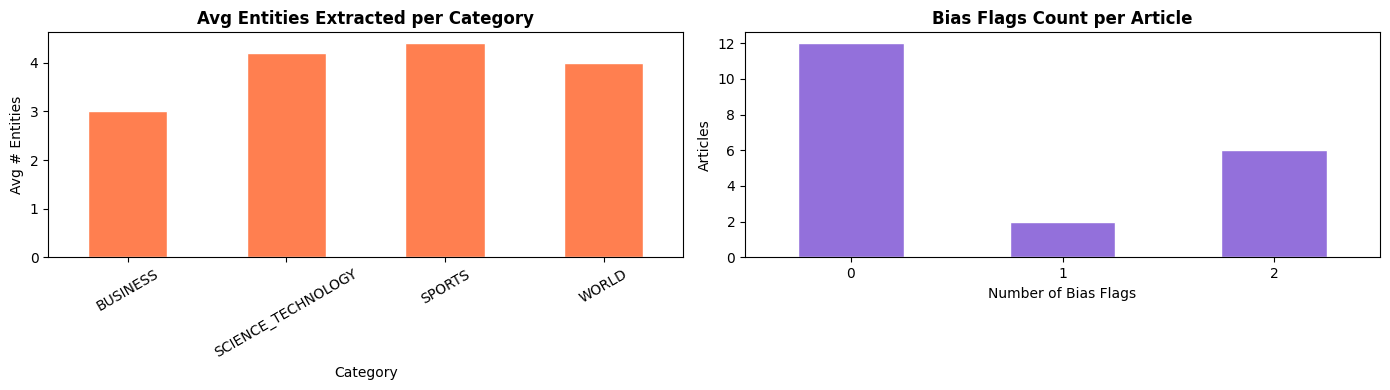

In [34]:
# ── Entity extraction stats ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Average entities per category
ent_by_cat = df_ok_b.groupby("true_label")["num_entities"].mean()
ent_by_cat.plot(kind="bar", ax=axes[0], color="coral", edgecolor='white')
axes[0].set_title("Avg Entities Extracted per Category", fontweight='bold')
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Avg # Entities")
axes[0].tick_params(axis='x', rotation=30)

# Bias flags frequency
bias_counts = df_ok_b["bias_flags"].apply(lambda x: len(x) if isinstance(x, list) else 0)
bias_counts.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="mediumpurple", edgecolor='white'
)
axes[1].set_title("Bias Flags Count per Article", fontweight='bold')
axes[1].set_xlabel("Number of Bias Flags")
axes[1].set_ylabel("Articles")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("entity_bias_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. Code Complexity Comparison

One of BAML's core claims is reducing boilerplate. Let's count it.

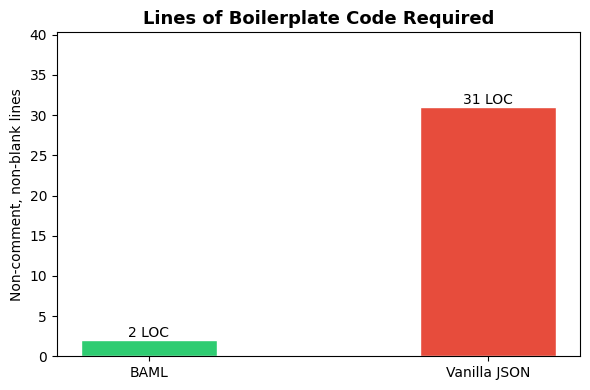

BAML: 2 LOC vs Vanilla: 31 LOC  →  15.5x more boilerplate without BAML


In [ ]:
baml_lines = """
# BAML approach (schema in .baml + generated client)

# 1. Define schema in news.baml (~30 lines, once)
# 2. Run: baml generate
# 3. Use:

from baml_client.sync_client import b
result = b.AnalyzeArticle(headline=h, body=text)
# result is fully typed - autocomplete works, mypy passes
# result.category is a NewsCategory enum
# result.entities is List[Entity]
# Malformed JSON, preamble, markdown wrapping - all handled by SAP
"""

vanilla_lines = """
# Vanilla approach (what you'd write without BAML)

import json
from openai import OpenAI
from pydantic import BaseModel, validator
from typing import List, Literal
import re

class Entity(BaseModel):
    name: str
    entity_type: str
    relevance_score: float

class ArticleAnalysis(BaseModel):
    headline_rewrite: str
    category: Literal["WORLD","SPORTS","BUSINESS","SCIENCE_TECHNOLOGY",...]
    sentiment: Literal["POSITIVE","NEGATIVE","NEUTRAL"]
    sentiment_confidence: float
    entities: List[Entity]
    key_claims: List[str]
    summary: str
    bias_flags: List[str]

SYSTEM_PROMPT = \"\"\"... (50+ line prompt with JSON schema docs) ...\"\"\"

client = OpenAI()
def analyze(headline, body):
    resp = client.chat.completions.create(
        model="gpt-4o-mini", temperature=0,
        response_format={"type": "json_object"},
        messages=[{"role":"system","content":SYSTEM_PROMPT},
                  {"role":"user",  "content":f"{headline}\\n{body}"}]
    )
    raw = resp.choices[0].message.content
    # Strip markdown fences if model wraps in ```json
    raw = re.sub(r'^```json|```$', '', raw, flags=re.MULTILINE).strip()
    parsed = json.loads(raw)   # still crashes on malformed JSON
    return ArticleAnalysis(**parsed)
"""

baml_loc = len([l for l in baml_lines.splitlines() if l.strip() and not l.strip().startswith('#')])
vanilla_loc = len([l for l in vanilla_lines.splitlines() if l.strip() and not l.strip().startswith('#')])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["BAML", "Vanilla JSON"], [baml_loc, vanilla_loc],
              color=["#2ecc71", "#e74c3c"], edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%d LOC')
ax.set_title("Lines of Boilerplate Code Required", fontweight='bold', fontsize=13)
ax.set_ylabel("Non-comment, non-blank lines")
ax.set_ylim(0, vanilla_loc * 1.3)
plt.tight_layout()
plt.savefig("code_complexity.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"BAML: {baml_loc} LOC vs Vanilla: {vanilla_loc} LOC  →  {vanilla_loc/baml_loc:.1f}x more boilerplate without BAML")


## 9. Side-by-Side Output Sample

Qualitative inspection: pick one article and show both BAML and vanilla outputs.

In [ ]:
idx = 0  # change to inspect a different article

row_b = df_baml.iloc[idx]
row_v = df_vanilla.iloc[idx]

print("=" * 70)
print(f"HEADLINE: {row_b['headline']}")
print(f"TRUE LABEL: {row_b['true_label']}")
print("=" * 70)

print("\n BAML OUTPUT ")
if row_b["parse_success"]:
    print(f"  Category:   {row_b['predicted_category']}")
    print(f"  Sentiment:  {row_b['sentiment']} ({row_b['sentiment_confidence']:.2f})")
    print(f"  Summary:    {row_b['summary']}")
    print(f"  Entities:   {[e.name for e in row_b['raw_obj'].entities]}")
    print(f"  Bias Flags: {row_b['bias_flags']}")
    print(f"  Headline Rewrite: {row_b['headline_rewrite']}")
else:
    print(f"  PARSE FAILED: {row_b.get('error')}")

print("\n VANILLA JSON OUTPUT ")
if row_v["parse_success"]:
    print(f"  Category:   {row_v['predicted_category']}")
    print(f"  Sentiment:  {row_v['sentiment']} ({row_v['sentiment_confidence']})")
    print(f"  Summary:    {row_v['summary']}")
    print(f"  Missing Keys: {row_v.get('missing_keys', [])}")
    print(f"  Type Error:   {row_v.get('type_error')}")
    print(f"  Enum Error:   {row_v.get('enum_error')}")
else:
    print(f"  PARSE FAILED: {row_v.get('error')}")

HEADLINE: Confident Bush Outlines Ambitious Plan for 2nd Term President Bush said he would begin work immediately on his proposal 
TRUE LABEL: WORLD

--- BAML OUTPUT ---
  Category:   POLITICS
  Sentiment:  POSITIVE (0.80)
  Summary:    President Bush outlines ambitious plan to overhaul Social Security, starting work immediately.
  Entities:   ['George W. Bush', 'Social Security']
  Bias Flags: []
  Headline Rewrite: President Bush Outlines Ambitious Plan for Second Term

--- VANILLA JSON OUTPUT ---
  Category:   POLITICS
  Sentiment:  POSITIVE (0.8)
  Summary:    President Bush has outlined an ambitious plan for his second term, which includes overhauling Social Security.
  Missing Keys: []
  Type Error:   False
  Enum Error:   False


---
## 10. Summary Dashboard

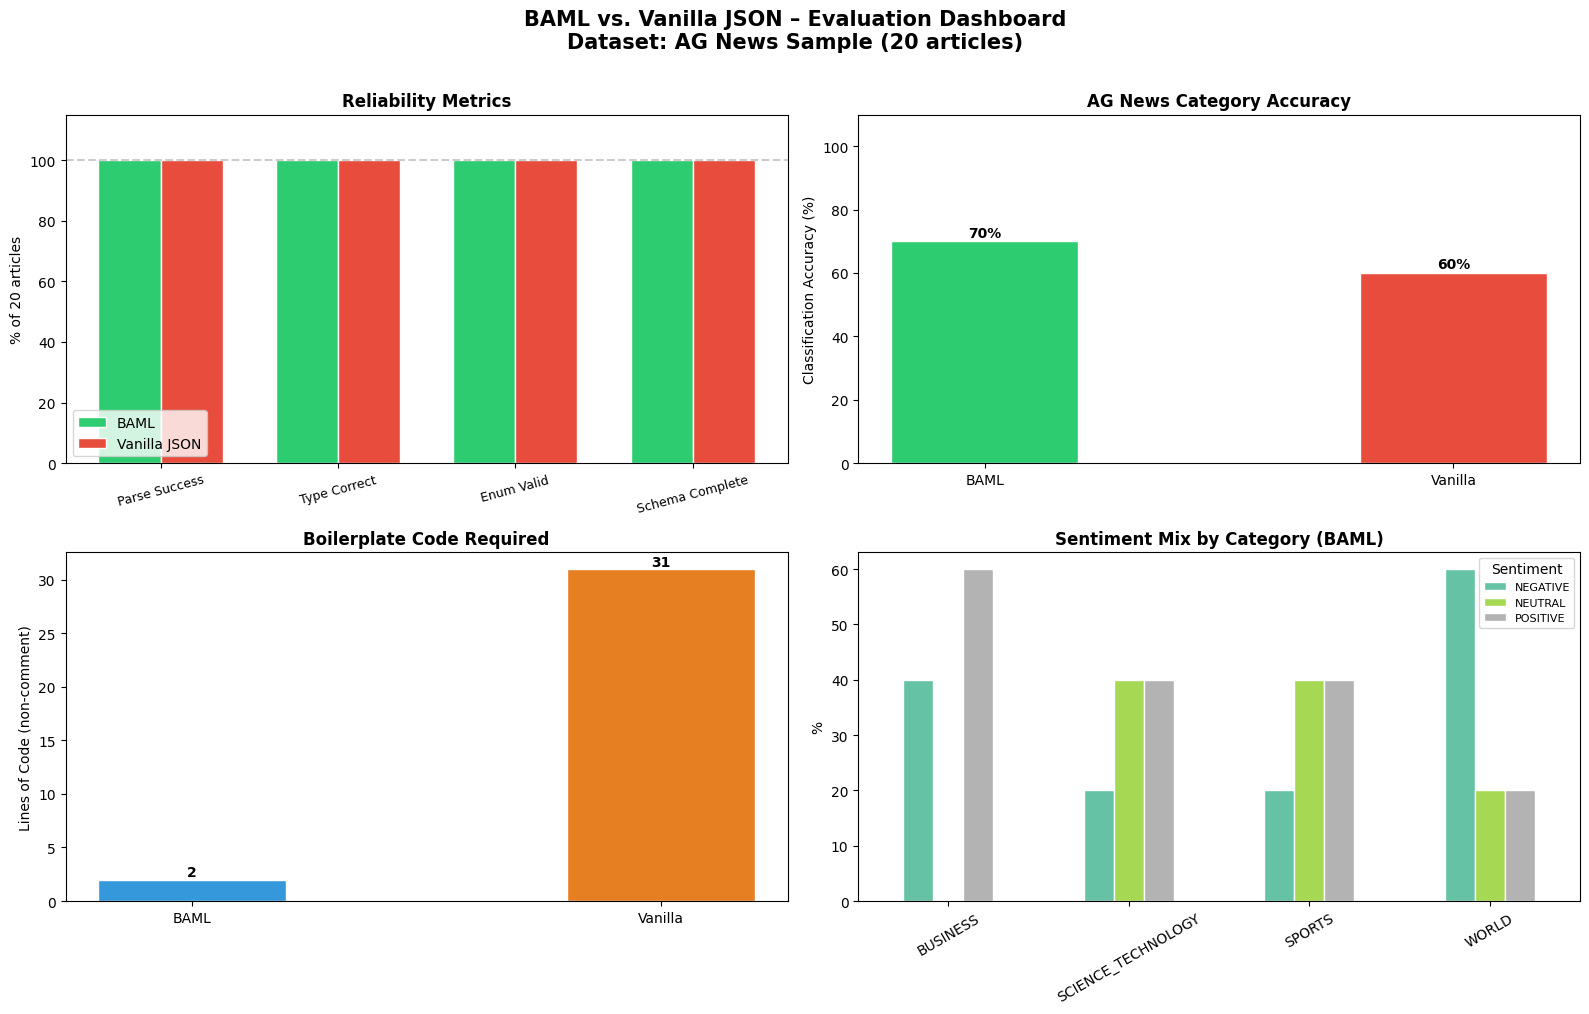

In [37]:
# ── 4-panel summary dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("BAML vs. Vanilla JSON – Evaluation Dashboard\nDataset: AG News Sample (20 articles)",
             fontsize=15, fontweight='bold', y=1.01)

# Panel 1: Reliability
ax1 = fig.add_subplot(2, 2, 1)
metrics = ["Parse Success", "Type Correct", "Enum Valid", "Schema Complete"]

def pct(s): return int(s.split('(')[1].replace('%)', ''))

baml_vals    = [pct(rel_baml[m])    for m in metrics]
vanilla_vals = [pct(rel_vanilla[m]) for m in metrics]
x = range(len(metrics))
w = 0.35
ax1.bar([i-w/2 for i in x], baml_vals,    w, label='BAML',         color='#2ecc71', edgecolor='white')
ax1.bar([i+w/2 for i in x], vanilla_vals, w, label='Vanilla JSON', color='#e74c3c', edgecolor='white')
ax1.set_xticks(list(x))
ax1.set_xticklabels(metrics, fontsize=9, rotation=15)
ax1.set_ylim(0, 115)
ax1.set_ylabel("% of 20 articles")
ax1.set_title("Reliability Metrics", fontweight='bold')
ax1.legend()
ax1.axhline(100, color='gray', linestyle='--', alpha=0.4)

# Panel 2: Accuracy
ax2 = fig.add_subplot(2, 2, 2)
ax2.bar(["BAML", "Vanilla"], [acc_b * 100, acc_v * 100],
        color=["#2ecc71", "#e74c3c"], edgecolor='white', width=0.4)
ax2.set_ylabel("Classification Accuracy (%)")
ax2.set_title("AG News Category Accuracy", fontweight='bold')
ax2.set_ylim(0, 110)
for i, v in enumerate([acc_b * 100, acc_v * 100]):
    ax2.text(i, v + 1.5, f"{v:.0f}%", ha='center', fontweight='bold')

# Panel 3: Boilerplate LOC
ax3 = fig.add_subplot(2, 2, 3)
ax3.bar(["BAML", "Vanilla"], [baml_loc, vanilla_loc],
        color=["#3498db", "#e67e22"], edgecolor='white', width=0.4)
ax3.set_ylabel("Lines of Code (non-comment)")
ax3.set_title("Boilerplate Code Required", fontweight='bold')
for i, v in enumerate([baml_loc, vanilla_loc]):
    ax3.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Panel 4: Sentiment by category (BAML)
ax4 = fig.add_subplot(2, 2, 4)
if "sentiment" in df_ok_b.columns:
    sent_pct = df_ok_b.groupby(["true_label", "sentiment"]).size().unstack(fill_value=0)
    sent_pct = sent_pct.div(sent_pct.sum(axis=1), axis=0) * 100
    sent_pct.plot(kind="bar", ax=ax4, colormap="Set2", edgecolor='white')
    ax4.set_title("Sentiment Mix by Category (BAML)", fontweight='bold')
    ax4.set_xlabel("")
    ax4.set_ylabel("%")
    ax4.tick_params(axis='x', rotation=30)
    ax4.legend(title="Sentiment", fontsize=8)

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches='tight')
plt.show()


## 11. Findings & Investment Memo Notes

**What BAML does well:**
- Zero boilerplate for structured output - schema → type-safe Python client in one command
- SAP handles malformed JSON, markdown fences, chain-of-thought preamble - cases that silently break vanilla pipelines in production
- Works with *any* model, not just OpenAI (Anthropic, Mistral, open-source via Ollama)
- VS Code playground gives instant prompt-to-output feedback without burning tokens on full runs
- Streaming support with typed partial objects - rare in the ecosystem

**Gaps / risks observed:**
- `baml generate` must be re-run after every schema change - breaks Jupyter's hot-reload workflow (documented workaround exists but is clunky)
- No built-in cost tracking or token budgeting per function call
- The `.baml` DSL is another language to learn - non-trivial onboarding for teams not already in the structured-output mindset
- Async client is separate from sync client (`async_client.py` vs `sync_client.py`) - easy to import the wrong one
- Community is small; StackOverflow answers don't exist yet for edge cases

**Competitive moat:**
- SAP parser is genuinely differentiated research - outperforms GPT-4o native structured outputs in their own benchmark
- Timing is right: every company building on LLMs hits structured output pain within weeks of starting
- Instrumentation-first design (every call is observable) aligns with enterprise compliance needs

**Recommended next steps if investing:**
1. Benchmark SAP vs. Outlines/Guidance (constrained decoding) for latency/reliability tradeoff
2. Interview 5-10 production users on the schema migration experience (changing a field type in prod is still painful)
3. Understand whether BAML stays a library or becomes a managed platform (pricing model is key)


Notebook by Anisha Pattanayak | BSV AI Fellow Application | May 2026*